# RF: Global vs. Position-Stratified

We test whether training a **separate model per position group** improves over a single global model.
The key difference: the position-stratified model fits TF-IDF **within each position**, so IDF weights
are position-specific. 'Explosive' for a WR gets a different weight than 'explosive' for an OL.

| Model | Features | IDF scope |
|-------|----------|-----------|
| **Global** | grade + Pos_Group (one-hot) + TF-IDF | All players |
| **Stratified** | grade + TF-IDF (one RF per stratum) | Within stratum |

## 1. Imports

In [3]:
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import ceil

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import average_precision_score, PrecisionRecallDisplay

nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

warnings.filterwarnings('ignore')
RANDOM_STATE = 42

## 2. Controls

In [4]:
# ── Data filters ───────────────────────────────────────────────────────────────
YEAR_MIN  = 2014
YEAR_MAX  = 2021
GRADE_MAX = 8.5   # excludes known data-entry outliers

# ── Stratification level ───────────────────────────────────────────────────────
# Controls which column is used to split the position-stratified model.
#   'position'  → 31 granular codes (CB, WR, OT, SAF…) — some very small
#   'Pos_Group' → 10 groups (DB, OL, WR, EDGE, RB, DT, LB, TE, QB, SPECIAL)
#   'Group'     → 8 broad groups (SKILL O, COMBO D, BIG O…)
STRAT_LEVEL = 'Pos_Group'

# Strata with fewer than this many players are excluded from the stratified model
# (too few samples → CV folds may have no positives → errors).
MIN_GROUP_N = 50

# ── Text ───────────────────────────────────────────────────────────────────────
NGRAM_RANGE = (1, 2)    # unigrams + bigrams

# Outcome-leaking phrases stripped before any processing.
PHRASE_BLOCKLIST = {
    'undrafted free agent', 'practice squad', 'free agent', 'early starter',
    'pro bowl', 'late round', 'undrafted free', 'make roster', 'rostered'
}

TARGET = 'made_it_contract'

## 3. Load & Preprocess

In [5]:
df = pd.read_csv('../data/processed/draft_enriched_with_contracts.csv')

# ── Apply filters ──────────────────────────────────────────────────────────────
df = df[(df['year'] >= YEAR_MIN) & (df['year'] <= YEAR_MAX)].copy()
df = df[df['grade'] <= GRADE_MAX].copy()
df = df.dropna(subset=[TARGET, 'grade', 'Pos_Group', 'Group', STRAT_LEVEL]).copy()
df[TARGET] = df[TARGET].astype(int)

# ── Combine text fields ────────────────────────────────────────────────────────
df['combined_text'] = (
    df['overview'].fillna('') + ' ' +
    df['strengths'].fillna('') + ' ' +
    df['weaknesses'].fillna('')
).str.strip()
df = df[df['combined_text'] != ''].copy().reset_index(drop=True)

print(f'Rows after filters: {len(df)}')
print(f'Positive rate: {df[TARGET].mean():.1%}')
print(f'\n{STRAT_LEVEL} distribution:')
print(df[STRAT_LEVEL].value_counts().to_string())

Rows after filters: 3239
Positive rate: 31.2%

Pos_Group distribution:
Pos_Group
DB         608
OL         548
WR         462
EDGE       416
RB         299
DT         270
LB         239
TE         179
QB         142
SPECIAL     76


In [6]:
lemmatizer = WordNetLemmatizer()
stop_words  = set(stopwords.words('english'))
_sorted_phrases = sorted(PHRASE_BLOCKLIST, key=len, reverse=True)

def remove_phrases(text: str) -> str:
    text = text.lower()
    for phrase in _sorted_phrases:
        text = text.replace(phrase, ' ')
    return text

def preprocess(text: str) -> str:
    if not isinstance(text, str) or not text.strip():
        return ''
    text = remove_phrases(text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    tokens = [
        lemmatizer.lemmatize(w)
        for w in text.split()
        if w not in stop_words and len(w) > 1
    ]
    return ' '.join(tokens)

df['text_preproc'] = df['combined_text'].apply(preprocess)
df = df[df['text_preproc'] != ''].copy().reset_index(drop=True)
print(f'Docs after preprocessing: {len(df)}')

Docs after preprocessing: 3239


## 4. Global Model

Single RF trained on all players. IDF is computed across the full corpus.
Position is controlled via one-hot encoding alongside TF-IDF features.

In [7]:
# ── Shared RF hyperparameters ──────────────────────────────────────────────────
# Using best params found from grid search in rf_text_grade_made_it.ipynb.
RF_PARAMS = dict(
    n_estimators=300, max_depth=20, min_samples_leaf=5,
    class_weight='balanced', random_state=RANDOM_STATE
)

# ── Global text pipeline ───────────────────────────────────────────────────────
# Standard TF-IDF — IDF is computed across all players in the training fold.
def make_global_text_pipe():
    return Pipeline([
        ('vect',  CountVectorizer(ngram_range=NGRAM_RANGE, max_df=0.5, min_df=0.005)),
        ('tfidf', TfidfTransformer(use_idf=True, norm='l2')),
    ])

# ── Global pipeline: grade + position (one-hot) + TF-IDF ──────────────────────
global_pre = ColumnTransformer([
    ('text',  make_global_text_pipe(),                                             'text_preproc'),
    ('grade', 'passthrough',                                                        ['grade']),
    ('pos',   OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), ['Pos_Group']),
], remainder='drop')

pipe_global = Pipeline([
    ('pre', global_pre),
    ('clf', RandomForestClassifier(**RF_PARAMS)),
])

print('Global pipeline defined.')

Global pipeline defined.


In [8]:
X_all = df[['text_preproc', 'grade', 'Pos_Group']].copy()
y_all = df[TARGET].values

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# OOF predicted probabilities for the global model
global_oof = cross_val_predict(
    pipe_global, X_all, y_all,
    cv=cv5, method='predict_proba', n_jobs=-1, verbose=1
)[:, 1]

global_pr_auc = average_precision_score(y_all, global_oof)
baseline      = y_all.mean()

print(f'Global model  PR-AUC = {global_pr_auc:.4f}')
print(f'Random baseline       = {baseline:.4f}')

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 14 concurrent workers.


Global model  PR-AUC = 0.4967
Random baseline       = 0.3118


[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:    8.8s remaining:   13.2s
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    8.9s finished


## 5. Position-Stratified Model

A separate RF is trained per stratum (determined by `STRAT_LEVEL`). Each model:
- Uses only players from that position group
- Fits TF-IDF **within** the training fold → IDF weights are position-specific
- Uses grade as the only structured feature (no position one-hot needed)

OOF predictions are collected across all strata and concatenated for an overall PR-AUC.

In [9]:
def make_strat_pipe():
    """
    Pipeline for a single position stratum.

    min_df is set higher (0.05) than the global model because each position
    subset is much smaller — a term must appear in at least 5% of that
    position's reports to be included, filtering out idiosyncratic noise.

    sublinear_tf=True replaces raw TF with 1+log(TF), dampening the effect
    of repeated terms in short scout reports.
    """
    text_pipe = Pipeline([
        ('vect',  CountVectorizer(ngram_range=NGRAM_RANGE, max_df=0.7, min_df=0.05)),
        ('tfidf', TfidfTransformer(use_idf=True, norm='l2', sublinear_tf=True)),
    ])
    pre = ColumnTransformer([
        ('text',  text_pipe,       'text_preproc'),
        ('grade', 'passthrough',   ['grade']),
    ], remainder='drop')
    return Pipeline([
        ('pre', pre),
        ('clf', RandomForestClassifier(**RF_PARAMS)),
    ])

In [10]:
strat_oof   = np.full(len(df), np.nan)   # will be filled in by index position
strat_results = []                        # per-stratum summary rows

for grp in sorted(df[STRAT_LEVEL].dropna().unique()):
    mask    = (df[STRAT_LEVEL] == grp).values
    grp_df  = df[mask].copy()
    n       = len(grp_df)
    n_pos   = grp_df[TARGET].sum()
    pos_rate = n_pos / n

    # Skip strata that are too small for reliable CV
    if n < MIN_GROUP_N:
        print(f'  SKIP {grp:<12s}  n={n} (< MIN_GROUP_N={MIN_GROUP_N})')
        continue

    # Fewer folds for smaller groups to keep enough positives per fold
    n_folds = 5 if n >= 150 else 3

    if n_pos < n_folds:
        print(f'  SKIP {grp:<12s}  n_pos={n_pos} < n_folds={n_folds}')
        continue

    X_grp = grp_df[['text_preproc', 'grade']].copy()
    y_grp = grp_df[TARGET].values

    cv_grp = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=RANDOM_STATE)
    oof    = cross_val_predict(
        make_strat_pipe(), X_grp, y_grp,
        cv=cv_grp, method='predict_proba', n_jobs=-1
    )[:, 1]

    # Store OOF predictions at the correct positions in the full array
    strat_oof[mask] = oof

    pr_auc = average_precision_score(y_grp, oof)
    strat_results.append({
        'stratum':   grp,
        'n':         n,
        'n_pos':     int(n_pos),
        'pos_rate':  pos_rate,
        'pr_auc':    pr_auc,
        'baseline':  pos_rate,   # random baseline = positive rate for that stratum
        'n_folds':   n_folds,
    })
    print(f'  {grp:<12s}  n={n:>4d}  pos_rate={pos_rate:.1%}  PR-AUC={pr_auc:.4f}  ({n_folds}-fold)')

strat_df = pd.DataFrame(strat_results).sort_values('pr_auc', ascending=False)

# Overall stratified PR-AUC — uses only rows where we have OOF predictions
valid = ~np.isnan(strat_oof)
strat_pr_auc = average_precision_score(y_all[valid], strat_oof[valid])
print(f'\nStratified overall  PR-AUC = {strat_pr_auc:.4f}  (n={valid.sum()} / {len(df)})')

  DB            n= 608  pos_rate=31.2%  PR-AUC=0.4064  (5-fold)
  DT            n= 270  pos_rate=33.0%  PR-AUC=0.5735  (5-fold)
  EDGE          n= 416  pos_rate=34.4%  PR-AUC=0.5423  (5-fold)
  LB            n= 239  pos_rate=34.3%  PR-AUC=0.4573  (5-fold)
  OL            n= 548  pos_rate=35.4%  PR-AUC=0.5092  (5-fold)
  QB            n= 142  pos_rate=31.0%  PR-AUC=0.6477  (3-fold)
  RB            n= 299  pos_rate=25.8%  PR-AUC=0.3350  (5-fold)
  SPECIAL       n=  76  pos_rate=38.2%  PR-AUC=0.4455  (3-fold)
  TE            n= 179  pos_rate=31.8%  PR-AUC=0.4995  (5-fold)
  WR            n= 462  pos_rate=22.7%  PR-AUC=0.3982  (5-fold)

Stratified overall  PR-AUC = 0.4713  (n=3239 / 3239)


## 6. Comparison

In [11]:
print('── Summary ───────────────────────────────────────────')
print(f'  Global (grade + pos one-hot + TF-IDF)  PR-AUC = {global_pr_auc:.4f}')
print(f'  Stratified (per-{STRAT_LEVEL})          PR-AUC = {strat_pr_auc:.4f}')
print(f'  Random baseline (positive rate)         PR-AUC = {baseline:.4f}')
print()
print('── Per-stratum results ───────────────────────────────')
display_df = strat_df[['stratum', 'n', 'n_pos', 'pos_rate', 'pr_auc', 'baseline']].copy()
display_df['lift'] = display_df['pr_auc'] - display_df['baseline']
display_df['pos_rate'] = display_df['pos_rate'].map('{:.1%}'.format)
display_df['baseline'] = display_df['baseline'].map('{:.3f}'.format)
display_df['pr_auc']   = display_df['pr_auc'].map('{:.4f}'.format)
display_df['lift']     = display_df['lift'].map('{:+.4f}'.format)
print(display_df.to_string(index=False))

── Summary ───────────────────────────────────────────
  Global (grade + pos one-hot + TF-IDF)  PR-AUC = 0.4967
  Stratified (per-Pos_Group)          PR-AUC = 0.4713
  Random baseline (positive rate)         PR-AUC = 0.3118

── Per-stratum results ───────────────────────────────
stratum   n  n_pos pos_rate pr_auc baseline    lift
     QB 142     44    31.0% 0.6477    0.310 +0.3378
     DT 270     89    33.0% 0.5735    0.330 +0.2439
   EDGE 416    143    34.4% 0.5423    0.344 +0.1985
     OL 548    194    35.4% 0.5092    0.354 +0.1552
     TE 179     57    31.8% 0.4995    0.318 +0.1811
     LB 239     82    34.3% 0.4573    0.343 +0.1142
SPECIAL  76     29    38.2% 0.4455    0.382 +0.0639
     DB 608    190    31.2% 0.4064    0.312 +0.0939
     WR 462    105    22.7% 0.3982    0.227 +0.1709
     RB 299     77    25.8% 0.3350    0.258 +0.0775


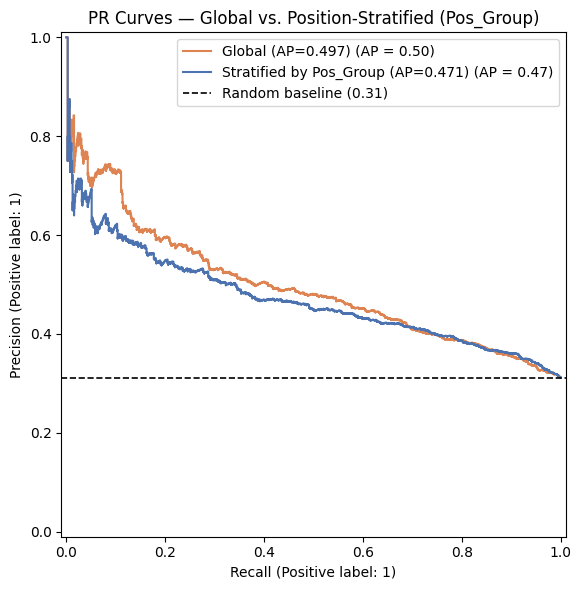

In [12]:
fig, ax = plt.subplots(figsize=(8, 6))

PrecisionRecallDisplay.from_predictions(
    y_all, global_oof, ax=ax,
    name=f'Global (AP={global_pr_auc:.3f})',
    color='#DD8452'
)
PrecisionRecallDisplay.from_predictions(
    y_all[valid], strat_oof[valid], ax=ax,
    name=f'Stratified by {STRAT_LEVEL} (AP={strat_pr_auc:.3f})',
    color='#4C72B0'
)
ax.axhline(y=baseline, color='k', linestyle='--', linewidth=1.2,
           label=f'Random baseline ({baseline:.2f})')
ax.set_title(f'PR Curves — Global vs. Position-Stratified ({STRAT_LEVEL})')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

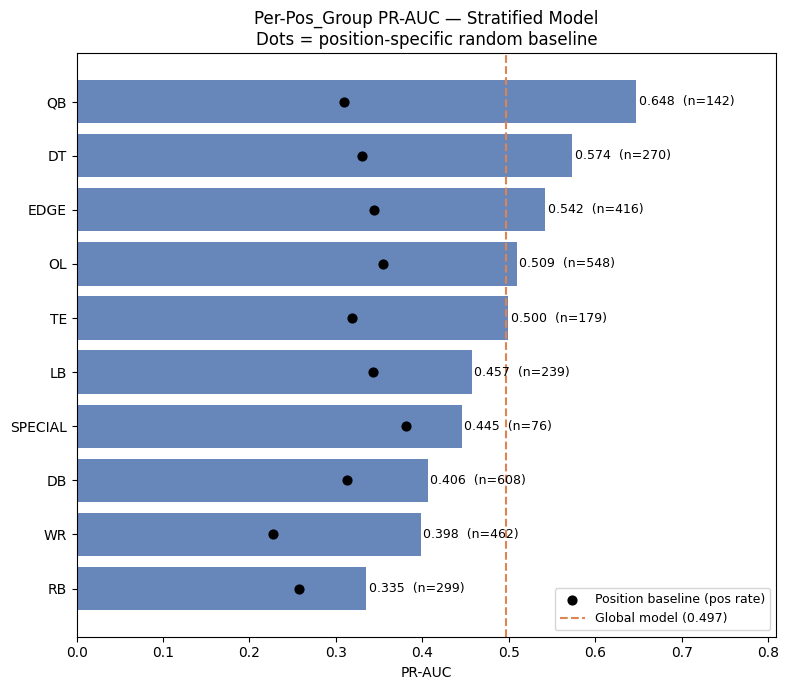

In [13]:
# Per-stratum PR-AUC bar chart, sorted descending
plot_df = strat_df.sort_values('pr_auc', ascending=True)

fig, ax = plt.subplots(figsize=(8, 0.55 * len(plot_df) + 1.5))

bars = ax.barh(plot_df['stratum'], plot_df['pr_auc'], color='#4C72B0', alpha=0.85)

# Mark each bar's random baseline as a dot
ax.scatter(plot_df['baseline'], plot_df['stratum'],
           color='k', zorder=5, s=40, label='Position baseline (pos rate)')

# Label bars with PR-AUC and n
for bar, row in zip(bars, plot_df.itertuples()):
    ax.text(
        bar.get_width() + 0.003, bar.get_y() + bar.get_height() / 2,
        f'{row.pr_auc:.3f}  (n={row.n})',
        va='center', fontsize=9
    )

ax.axvline(global_pr_auc, color='#DD8452', linestyle='--', linewidth=1.5,
           label=f'Global model ({global_pr_auc:.3f})')
ax.set_xlabel('PR-AUC')
ax.set_title(f'Per-{STRAT_LEVEL} PR-AUC — Stratified Model\nDots = position-specific random baseline')
ax.legend(fontsize=9)
ax.set_xlim(0, plot_df['pr_auc'].max() * 1.25)
plt.tight_layout()
plt.show()

## 7. Top TF-IDF Features per Stratum

Refit each position model on the **full** stratum data and inspect the RF feature importances.
These are the words most useful for predicting second contracts **within** each position group.

In [14]:
TOP_N = 15
feat_results = {}   # stratum → DataFrame of top features

for grp in sorted(df[STRAT_LEVEL].dropna().unique()):
    mask   = (df[STRAT_LEVEL] == grp).values
    grp_df = df[mask].copy()
    if len(grp_df) < MIN_GROUP_N:
        continue

    X_grp = grp_df[['text_preproc', 'grade']].copy()
    y_grp = grp_df[TARGET].values

    pipe = make_strat_pipe()
    pipe.fit(X_grp, y_grp)

    # Feature names from the ColumnTransformer
    ct    = pipe.named_steps['pre']
    names = ct.get_feature_names_out()
    imps  = pipe.named_steps['clf'].feature_importances_

    imp_df = pd.DataFrame({'feature': names, 'importance': imps})
    # Keep only text features (exclude grade)
    imp_df = imp_df[imp_df['feature'].str.startswith('text__')].copy()
    imp_df['feature'] = imp_df['feature'].str.replace('text__', '', regex=False)
    feat_results[grp] = imp_df.nlargest(TOP_N, 'importance').reset_index(drop=True)

print(f'Feature importances computed for {len(feat_results)} strata.')

Feature importances computed for 10 strata.


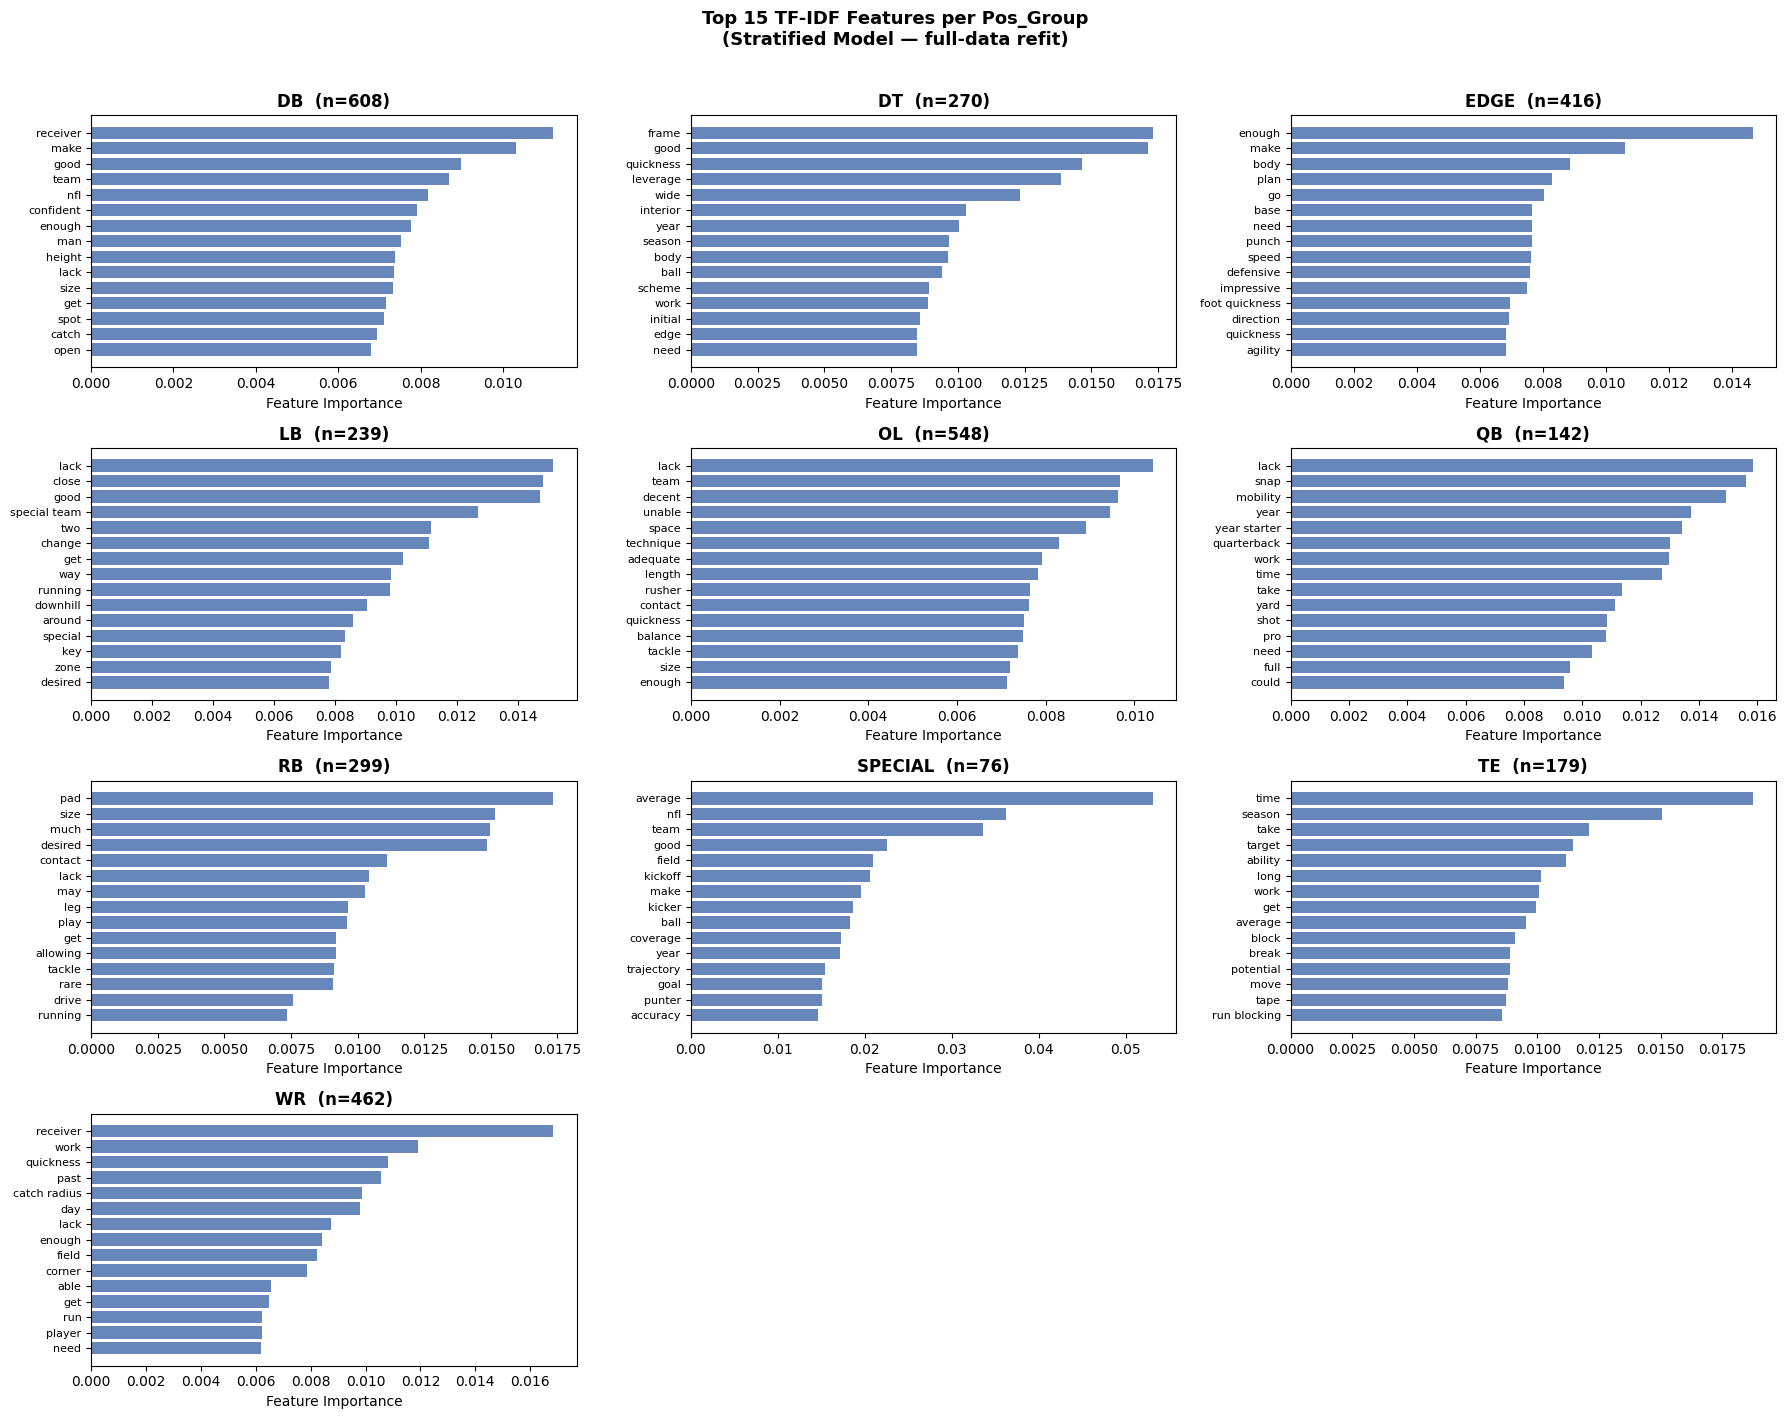

In [15]:
strata = list(feat_results.keys())
ncols  = 3
nrows  = ceil(len(strata) / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 3.5 * nrows))
axes = axes.flatten()

for i, grp in enumerate(sorted(strata)):
    ax   = axes[i]
    data = feat_results[grp].sort_values('importance')
    ax.barh(data['feature'], data['importance'], color='#4C72B0', alpha=0.85)
    ax.set_title(f'{grp}  (n={int(strat_df.set_index("stratum").loc[grp, "n"])})',
                 fontweight='bold')
    ax.set_xlabel('Feature Importance')
    ax.tick_params(axis='y', labelsize=8)

# Hide any unused subplots
for j in range(len(strata), len(axes)):
    axes[j].set_visible(False)

fig.suptitle(f'Top {TOP_N} TF-IDF Features per {STRAT_LEVEL}\n(Stratified Model — full-data refit)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 8. Position Deep Dive: Does Text Add Signal Beyond Grade?

We compare **grade only** vs **grade + text** for three positions chosen to represent different scenarios:

| Position | n | Stratified PR-AUC | Why interesting |
|----------|---|-------------------|-----------------|
| **QB** | 142 | 0.648 | Highest lift in Section 5 — does text actually help? |
| **EDGE** | 416 | 0.542 | Pass rush has specific vocabulary — best case for text |
| **RB** | 299 | 0.335 | Lowest lift in Section 5 — expected text adds nothing |

If grade+text ≤ grade-only, text provides no marginal signal for that position.

In [16]:
from sklearn.metrics import fbeta_score

# Positions to analyse and their CV fold count (5-fold if n >= 150, else 3)
FOCUS_POSITIONS = ['QB', 'EDGE', 'RB']

def n_folds_for(n):
    return 5 if n >= 150 else 3

def pos_metrics(y_true, oof_probs, threshold=0.3):
    """PR-AUC, F2, and Recall at a fixed threshold."""
    pr_auc = average_precision_score(y_true, oof_probs)
    preds  = (oof_probs >= threshold).astype(int)
    f2     = fbeta_score(y_true, preds, beta=2, zero_division=0)
    recall = preds[y_true == 1].mean()
    return pr_auc, f2, recall

# Pre-slice data and run OOF for both models per position
pos_data = {}   # pos → dict with y, oof_grade, oof_text, baseline, n_folds

for pos in FOCUS_POSITIONS:
    sub = df[df['Pos_Group'] == pos].copy().reset_index(drop=True)
    y   = sub[TARGET].values
    n   = len(sub)
    nf  = n_folds_for(n)
    cv  = StratifiedKFold(n_splits=nf, shuffle=True, random_state=RANDOM_STATE)

    # Grade only — single numeric feature, no pipeline pre-processing needed
    oof_g = cross_val_predict(
        RandomForestClassifier(**RF_PARAMS),
        sub[['grade']].values, y,
        cv=cv, method='predict_proba', n_jobs=-1
    )[:, 1]

    # Grade + Text — same stratified pipe used in Section 5
    oof_t = cross_val_predict(
        make_strat_pipe(),
        sub[['text_preproc', 'grade']].copy(), y,
        cv=cv, method='predict_proba', n_jobs=-1
    )[:, 1]

    pos_data[pos] = dict(
        sub=sub, y=y, n=n, n_folds=nf,
        baseline=y.mean(),
        oof_grade=oof_g,
        oof_text=oof_t,
    )
    print(f'{pos:<6}  n={n}  positive rate={y.mean():.1%}  ({nf}-fold CV)')

QB      n=142  positive rate=31.0%  (3-fold CV)
EDGE    n=416  positive rate=34.4%  (5-fold CV)
RB      n=299  positive rate=25.8%  (5-fold CV)


In [17]:
# ── Metric summary table ───────────────────────────────────────────────────────
print(f'{"":>16}  PR-AUC   F2       Recall@0.3')
print('─' * 55)

for pos, d in pos_data.items():
    print(f'\n{pos}  (n={d["n"]}, baseline={d["baseline"]:.2f})')
    for label, oof in [('Grade only', d['oof_grade']), ('Grade + Text', d['oof_text'])]:
        pr, f2, rec = pos_metrics(d['y'], oof)
        marker = '  ▲' if label == 'Grade + Text' and pr > pos_metrics(d['y'], d['oof_grade'])[0] else ''
        print(f'  {label:<14}  {pr:.4f}   {f2:.4f}   {rec:.4f}{marker}')

                  PR-AUC   F2       Recall@0.3
───────────────────────────────────────────────────────

QB  (n=142, baseline=0.31)
  Grade only      0.7080   0.7255   0.8409
  Grade + Text    0.6477   0.7368   0.9545

EDGE  (n=416, baseline=0.34)
  Grade only      0.5946   0.7360   0.8811
  Grade + Text    0.5423   0.7030   0.9301

RB  (n=299, baseline=0.26)
  Grade only      0.4136   0.5762   0.7662
  Grade + Text    0.3350   0.6072   0.8312


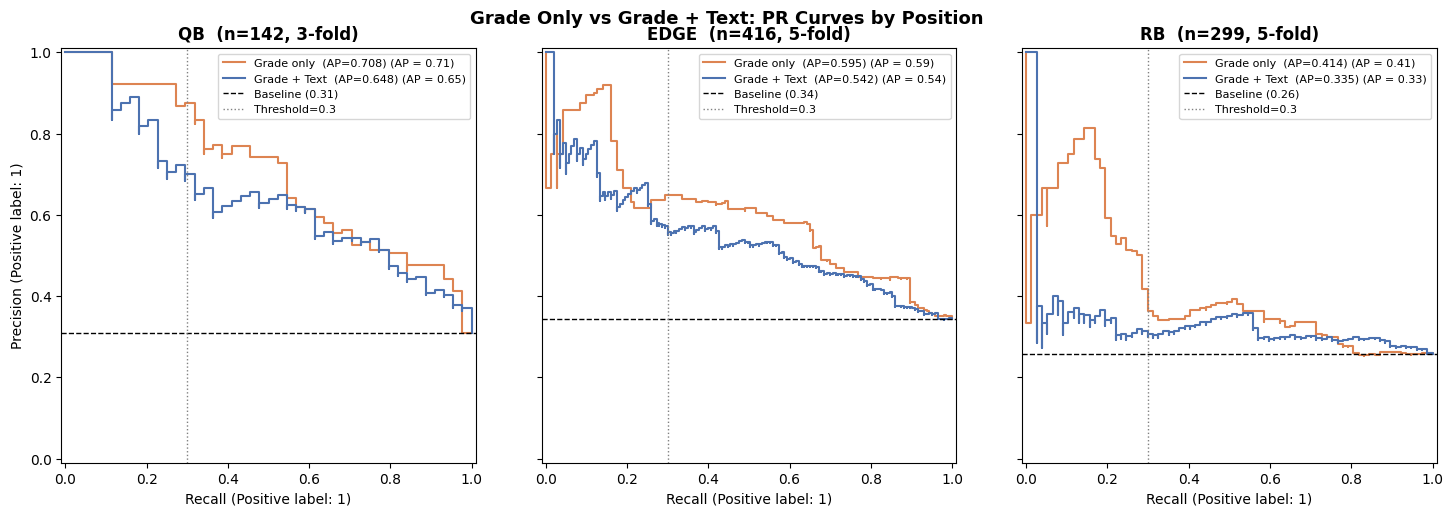

In [18]:
# ── PR curves: one subplot per position ───────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for ax, pos in zip(axes, FOCUS_POSITIONS):
    d = pos_data[pos]
    pr_g = average_precision_score(d['y'], d['oof_grade'])
    pr_t = average_precision_score(d['y'], d['oof_text'])

    PrecisionRecallDisplay.from_predictions(
        d['y'], d['oof_grade'], ax=ax,
        name=f'Grade only  (AP={pr_g:.3f})', color='#DD8452'
    )
    PrecisionRecallDisplay.from_predictions(
        d['y'], d['oof_text'], ax=ax,
        name=f'Grade + Text  (AP={pr_t:.3f})', color='#4C72B0'
    )
    ax.axhline(d['baseline'], color='k', linestyle='--', linewidth=1,
               label=f'Baseline ({d["baseline"]:.2f})')
    ax.axvline(0.3, color='gray', linestyle=':', linewidth=1, label='Threshold=0.3')
    ax.set_title(f'{pos}  (n={d["n"]}, {d["n_folds"]}-fold)', fontweight='bold')
    ax.legend(fontsize=8)
    if ax != axes[0]:
        ax.set_ylabel('')

fig.suptitle('Grade Only vs Grade + Text: PR Curves by Position', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

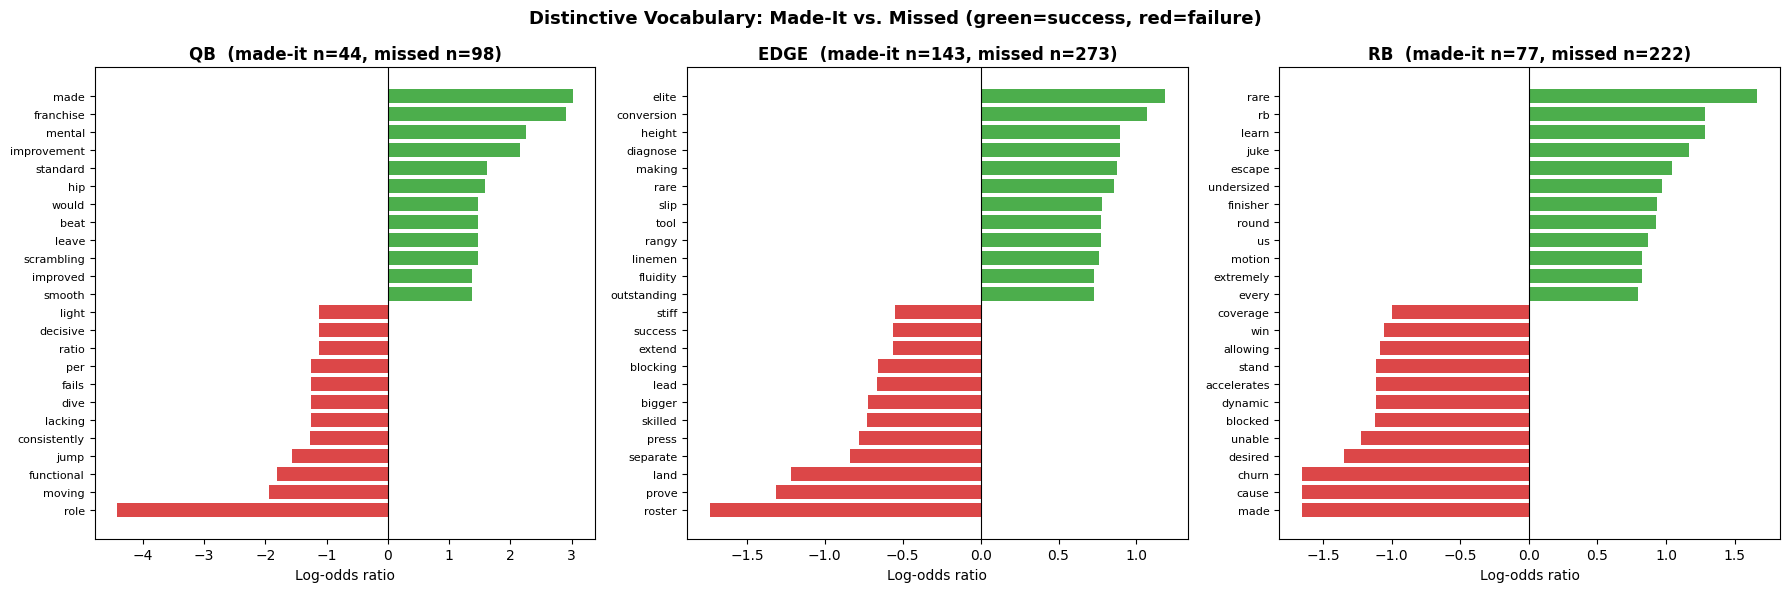

In [19]:
from sklearn.feature_extraction.text import CountVectorizer as CV

# ── Distinctive vocabulary per position ───────────────────────────────────────
# For each position, compute the log-odds ratio of word usage between players
# who earned a second contract vs. those who didn't.
# Log-odds > 0 → word appears more in made-it reports; < 0 → failure reports.

TOP_WORDS = 12
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, pos in zip(axes, FOCUS_POSITIONS):
    d   = pos_data[pos]
    sub = d['sub']
    y   = d['y']

    made_text   = sub.loc[y == 1, 'text_preproc'].tolist()
    missed_text = sub.loc[y == 0, 'text_preproc'].tolist()

    # Fit vocabulary on all players in this position so both groups share the index
    cv_vocab = CV(ngram_range=(1, 1), min_df=0.05, max_df=0.8, binary=True)
    cv_vocab.fit(sub['text_preproc'])

    rate_made  = cv_vocab.transform(made_text).toarray().mean(axis=0)
    rate_miss  = cv_vocab.transform(missed_text).toarray().mean(axis=0)

    eps = 1e-3
    log_odds = np.log((rate_made + eps) / (rate_miss + eps))

    vocab_df = pd.DataFrame({
        'word':     cv_vocab.get_feature_names_out(),
        'log_odds': log_odds,
    })
    plot_df = pd.concat([
        vocab_df.nlargest(TOP_WORDS, 'log_odds'),
        vocab_df.nsmallest(TOP_WORDS, 'log_odds'),
    ]).sort_values('log_odds')

    colors = ['#d62728' if v < 0 else '#2ca02c' for v in plot_df['log_odds']]
    ax.barh(plot_df['word'], plot_df['log_odds'], color=colors, alpha=0.85)
    ax.axvline(0, color='k', linewidth=0.8)
    ax.set_title(f'{pos}  (made-it n={y.sum()}, missed n={(y==0).sum()})',
                 fontweight='bold')
    ax.set_xlabel('Log-odds ratio')
    ax.tick_params(axis='y', labelsize=8)

fig.suptitle('Distinctive Vocabulary: Made-It vs. Missed (green=success, red=failure)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

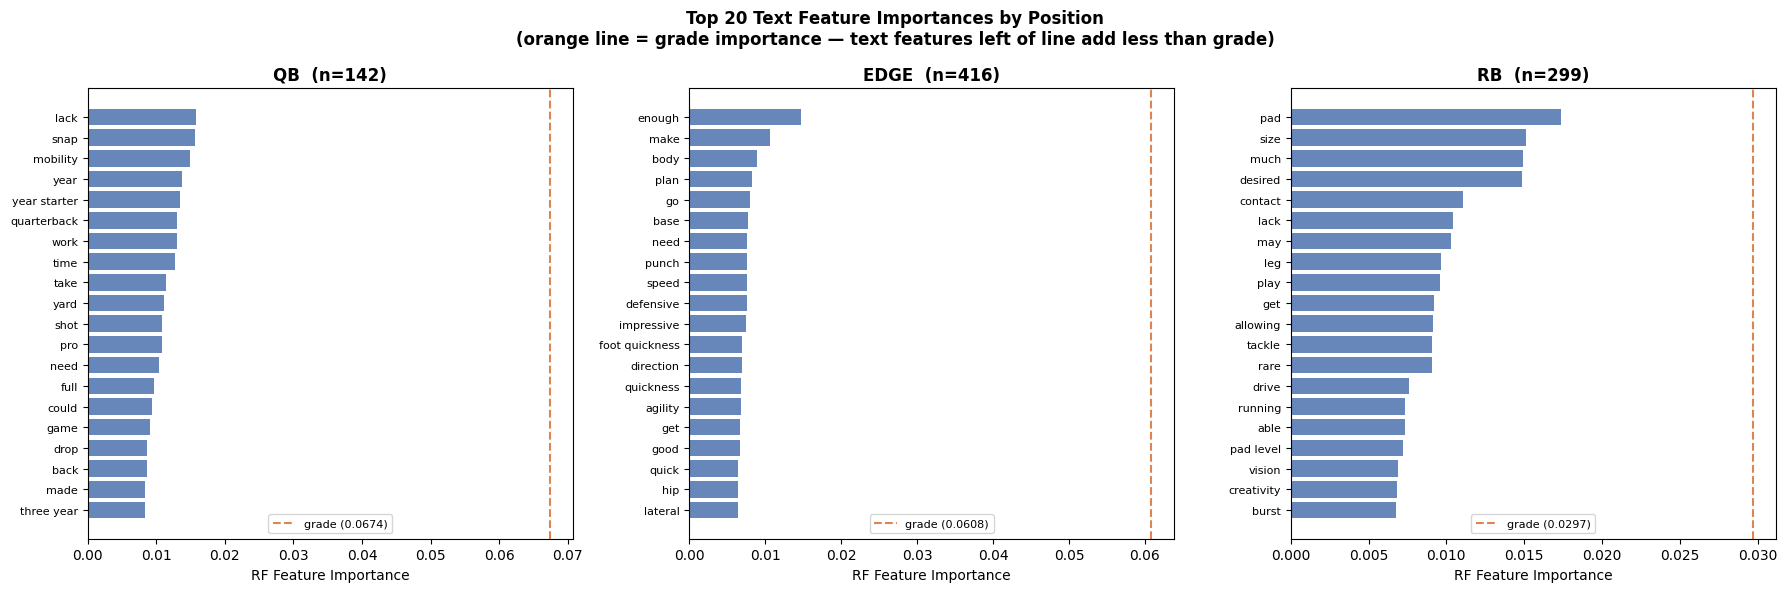

In [20]:
# ── RF feature importances: one subplot per position (full-data refit) ─────────
# Refit on all data per position to get stable importances.
# The orange dashed line shows grade's importance — text features above that
# line are contributing more than the grade feature itself.

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, pos in zip(axes, FOCUS_POSITIONS):
    d   = pos_data[pos]
    sub = d['sub']
    y   = d['y']

    pipe = make_strat_pipe()
    pipe.fit(sub[['text_preproc', 'grade']].copy(), y)

    names = pipe.named_steps['pre'].get_feature_names_out()
    imps  = pipe.named_steps['clf'].feature_importances_
    imp_df = pd.DataFrame({'feature': names, 'importance': imps})

    grade_imp = imp_df[imp_df['feature'] == 'grade__grade']['importance'].values[0]

    text_imp = imp_df[imp_df['feature'].str.startswith('text__')].copy()
    text_imp['feature'] = text_imp['feature'].str.replace('text__', '', regex=False)
    text_imp = text_imp.nlargest(20, 'importance').sort_values('importance')

    ax.barh(text_imp['feature'], text_imp['importance'], color='#4C72B0', alpha=0.85)
    ax.axvline(grade_imp, color='#DD8452', linestyle='--', linewidth=1.5,
               label=f'grade ({grade_imp:.4f})')
    ax.set_title(f'{pos}  (n={d["n"]})', fontweight='bold')
    ax.set_xlabel('RF Feature Importance')
    ax.legend(fontsize=8)
    ax.tick_params(axis='y', labelsize=8)

fig.suptitle('Top 20 Text Feature Importances by Position\n'
             '(orange line = grade importance — text features left of line add less than grade)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()